(graphene-nn)=
# Graphene n'th nearest neighbor hopping

This graphene model calculation illustrates a case where one can use `Lattice.nn_orb_bonds` to get the n'th nearest neighbor hoppings.

In [1]:
from pythtb import TBModel, WFArray, Mesh, Lattice
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# define lattice vectors
lat_vecs = [[1, 0], [1/2, np.sqrt(3)/2]]
# define coordinates of orbitals
orb_vecs = [[1/3, 1/3], [2/3, 2/3]]

lat = Lattice(lat_vecs, orb_vecs, periodic_dirs=[0, 1])

In [3]:
# make two dimensional tight-binding boron nitride model
nn_model = TBModel(lat)

## N'th nearest neighbor hoppings

In [4]:
N = 10
hops = [-np.exp(t) for t in range(N)]

In [5]:
nn_model.set_nn_hops(hops)

In [6]:
print(nn_model)

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
periodic directions         = [0, 1]
number of orbitals          = 2
number of spin components   = 1
number of electronic states = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283, -3.628]
  # 1 ===> [ 0.000,  7.255]
Volume of reciprocal unit cell = 45.586 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
----------------------------------------
Site energies:
  # 0 ===>  0.000 
  # 1 ===>  0.000 
Hoppings:
  < 0 | H | 1 + [-1.0 ,  0.0 ] >  ===> -1.0000
  < 0 | H | 1 + [ 0.0 , -1.0 ] >  ===> -1.0000
  < 0 | H | 1 + [ 0.0 ,  0.0 ] >  

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

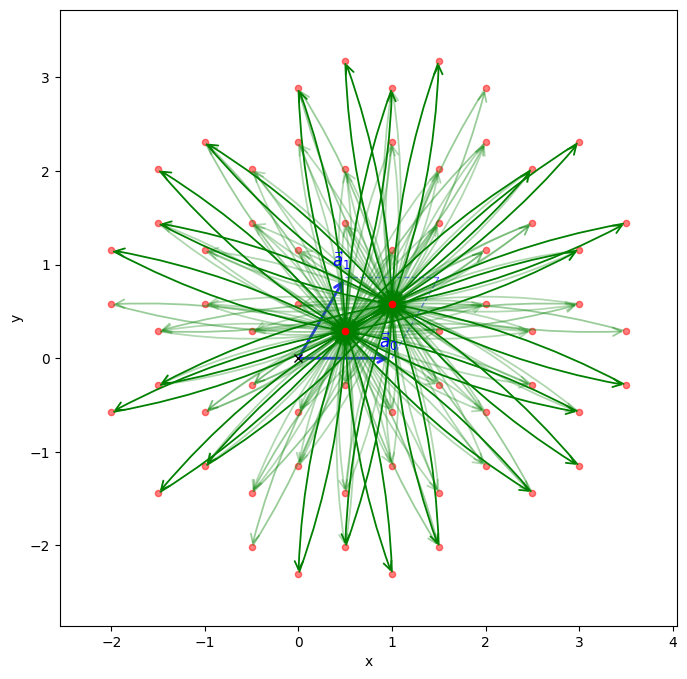

In [7]:
nn_model.visualize()

In [ ]:
# shells[0]

In [ ]:
# shells

In [ ]:
# shells

In [ ]:
# shells 

In [ ]:
shells[1]

[[(0, 1, (0, 0)), (0, 1, (0, -1)), (0, 1, (-1, 0))],
 [(0, 0, (1, 0)),
  (0, 0, (1, -1)),
  (0, 0, (0, 1)),
  (1, 1, (0, 1)),
  (1, 1, (1, -1)),
  (1, 1, (1, 0))]]

In [ ]:
n_shell = 2
shells = lat.nn_bonds(n_shell=n_shell)

# for s in range(n_shell):
#     print(f"shell {s}: {len(shells[s])} hops")
#     for (i, j, R) in shells[s]:
#         print(f"  {(i, j, R)}")
#         # Shell even: 3 AB (and/or BA) neighbors, purely real t1
#         if s%2 == 0:
#             nn_model.set_hop(t1 * 10**(-s), i, j, R)
#         else:
#             # Shell odd: 6 AA/BB next-nearest neighbors with complex phases ±phi
#             # Robustness: ensure these are same-sublattice
#             if i != j:
#                 raise RuntimeError(f"NNN shell contains cross-sublattice hop: {(i,j,R)}")
#             c = nnn_chirality(i, j, R)
#             nn_model.set_hop(t2 * 10**(-s) * np.exp(1j * c * phi), i, j, R)

In [ ]:
print(len(shells))

2


----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
periodic directions         = [0, 1]
number of orbitals          = 2
number of spin components   = 1
number of electronic states = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283, -3.628]
  # 1 ===> [ 0.000,  7.255]
Volume of reciprocal unit cell = 45.586 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
----------------------------------------
Site energies:
  # 0 ===>  0.000 
  # 1 ===>  0.000 
Hoppings:
Hopping distances:


ValueError: zero-size array to reduction operation maximum which has no identity

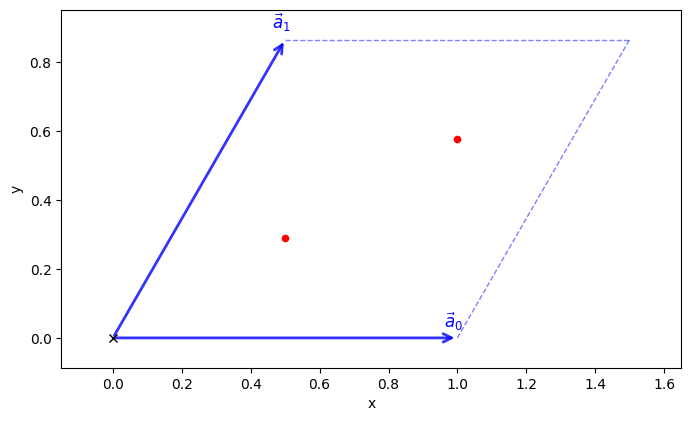

In [ ]:
print(nn_model)
nn_model.visualize()

In [ ]:
nnn_model = TBModel(lat)

In [ ]:
n_shell = 4
shells = lat.nn_orb_bonds(n_shell=n_shell)["bonds_by_shell"]

for s in range(n_shell):
    print(f"shell {s}: {len(shells[s])} hops")
    print(shells[s])
    for (i, j, R) in shells[s]:
        # Shell even: 3 AB (and/or BA) neighbors, purely real t1
        if s%2 == 0:
            nn_model.set_hop(t1 * 10**(-s), i, j, R)
        else:
            # Shell odd: 6 AA/BB next-nearest neighbors with complex phases ±phi
            # Robustness: ensure these are same-sublattice
            if i != j:
                raise RuntimeError(f"NNN shell contains cross-sublattice hop: {(i,j,R)}")
            c = nnn_chirality(i, j, R)
            nnn_model.set_hop(t2 * 10**(-s) * np.exp(1j * c * phi), i, j, R)

shell 0: 3 hops
[(0, 1, (-1, 0)), (0, 1, (0, 0)), (0, 1, (0, -1))]
shell 1: 6 hops
[(0, 0, (-1, 0)), (0, 0, (-1, 1)), (0, 0, (0, 1)), (1, 1, (-1, 1)), (1, 1, (0, -1)), (1, 1, (1, 0))]
shell 2: 3 hops
[(0, 1, (-1, 1)), (0, 1, (-1, -1)), (0, 1, (1, -1))]
shell 3: 6 hops
[(0, 1, (-2, 0)), (0, 1, (-2, 1)), (0, 1, (0, -2)), (0, 1, (0, 1)), (0, 1, (1, 0)), (0, 1, (1, -2))]


RuntimeError: NNN shell contains cross-sublattice hop: (0, 1, (-2, 0))

In [ ]:
path = [[0, 0], [2/3, 1/3], [1/2, 1/2], [0, 0]]
label = (r"$\Gamma $", r"$K$", r"$M$", r"$\Gamma $")
nk = 100
k_vec, k_dist, k_node = nnn_model.k_path(path, nk, report=False)

In [ ]:
evals_nn = nn_model.solve_ham(k_vec)
evals_nnn = nnn_model.solve_ham(k_vec)

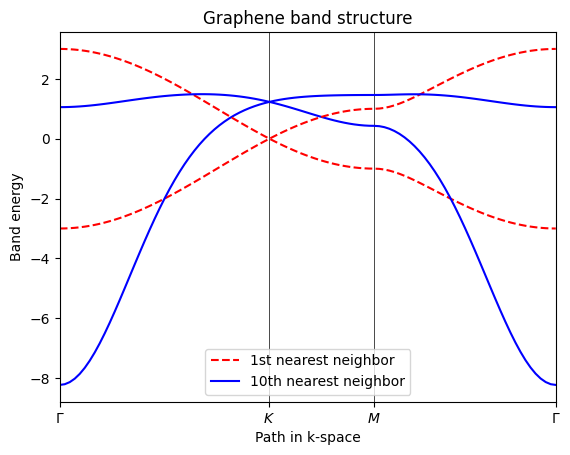

In [ ]:
fig, ax = plt.subplots()

ax.set_xlim(k_node[0], k_node[-1])
ax.set_xticks(k_node)
ax.set_xticklabels(label)

for n in range(len(k_node)):
    ax.axvline(x=k_node[n], linewidth=0.5, color="k")
    
ax.set_title("Graphene band structure")
ax.set_xlabel("Path in k-space")
ax.set_ylabel("Band energy")

# plot bands
for n in range(evals_nn.shape[1]):
    ax.plot(k_dist, evals_nn[:, n], color="r", linestyle="--", label="1st nearest neighbor" if n == 0 else "")
    ax.plot(k_dist, evals_nnn[:, n], color="b", linestyle="-", label=f"{n_shell}th nearest neighbor" if n == 0 else "")

ax.legend()

In [ ]:
nn_model=TBModel(lat)

In [ ]:

# --- find shells ---
out = lat.nn_orb_bonds(n_shell=8)  # enough to catch a second AB shell
shells = out["bonds_by_shell"]     # list[shell] of (i, j, R)

def first_shell_where(pred):
    for s, hops in enumerate(shells):
        if hops and all(pred(i,j,R) for (i,j,R) in hops):
            return s
    return None

NN  = first_shell_where(lambda i,j,R: i != j)  # nearest AB
NNN = first_shell_where(lambda i,j,R: i == j)  # nearest AA/BB
if NN is None or NNN is None:
    raise RuntimeError("Could not find NN or NNN shells.")

# pick the next AB shell beyond NN
AB2 = None
for s in range(NN+1, len(shells)):
    hops = shells[s]
    if hops and all(i != j for (i,j,R) in hops):
        AB2 = s
        break
if AB2 is None:
    raise RuntimeError("Could not find a more distant AB shell.")

print(f"Using shells: NN={NN}, NNN={NNN}, AB2={AB2}")

# --- parameters ---
t1  = 1.0
t2  = -0.4
phi = np.pi/2     # Haldane phase
M   = 1    # optional Semenoff mass; try also M=0 to see M-point closings
t3  = 0.    # we'll sweep this later

# --- NN real AB ---
for (i,j,R) in shells[NN]:
    nn_model.set_hop(t1, i, j, R)

# --- NNN complex AA/BB, geometric chirality ---
# Build the three primitive AA directions on the A sublattice from the NNN shell itself.
AA = [(i,j,R) for (i,j,R) in shells[NNN] if i==j==0]  # A->A subset
# pick three shortest distinct R's as the positive set
Rpos = set()
for (_,_,R) in AA:
    Rpos.add(tuple(map(int, R)))
    if len(Rpos) == 3: break
Rneg = {(-r1, -r2) for (r1, r2) in Rpos}

def nnn_sign(i, j, R):
    R = tuple(map(int, R))
    s = +1 if R in Rpos else (-1 if R in Rneg else 0)
    if s == 0:
        # Some lattices return equivalent R with different representatives; fold by modulo
        # (if you store lattice modulo elsewhere, use it; else leave this strict and raise)
        raise ValueError(f"Unexpected NNN displacement R={R}; check shell choice.")
    return s if (i==j==0) else -s  # flip sign on B

for (i,j,R) in shells[NNN]:
    if i != j: 
        raise RuntimeError(f"NNN shell is not same-sublattice: {(i,j,R)}")
    s = nnn_sign(i,j,R)
    nn_model.set_hop(t2 * np.exp(1j * s * phi), i, j, R)

# --- AB2 real hop t3 (start at 0.0; we'll sweep) ---
def apply_t3(val):
    for (i,j,R) in shells[AB2]:
        nn_model.set_hop(val, i, j, R)

apply_t3(t3)

# optional on-site Semenoff mass
if M != 0.0:
    for orb in range(nn_model.norb):
        m = +M if orb % 2 == 0 else -M   # A:+M, B:-M (assuming even=A, odd=B)
        nn_model.set_onsite(m, orb)

# # --- scan t3 and watch the topology ---
# def band_gap_and_chern(model, Nk=101):
#     # Replace with your own utilities; outline shown
#     # 1) sample BZ mesh, compute eigenvalues → min direct gap
#     # 2) compute Chern via your Berry-curvature routine
#     kmesh = mesh.make_kmesh(Nk, Nk, centered=True)  # your API
#     evals, evecs = model.solve_ham(kmesh, return_eigvecs=True)
#     gap = np.min(evals[:, n_occ] - evals[:, n_occ-1])  # adjust indexing to your code
#     C = berry.chern_number(evecs, kmesh, occ=n_occ)    # your WFArray or equivalent
#     return float(gap), int(round(C))

# for t3 in np.linspace(0.0, 0.6, 13):
#     apply_t3(t3)
#     gap, C = band_gap_and_chern(nn_model, Nk=81)
#     print(f"t3={t3:5.2f}  gap={gap:8.5f}  Chern={C}")

Using shells: NN=0, NNN=1, AB2=2


In [ ]:
evals_nn = nn_model.solve_ham(k_vec)

In [ ]:
nn_model.chern(occ_idxs=[0])

np.float64(0.0)

(<Figure size 640x480 with 2 Axes>, <Axes: ylabel='Energy $E(\\mathbf{{k}})$'>)

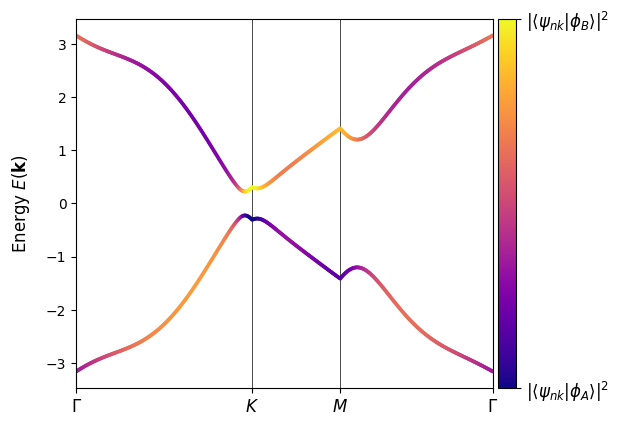

In [ ]:
nn_model.plot_bands(path, nk=500, k_label=label, proj_orb_idx=[0]) 

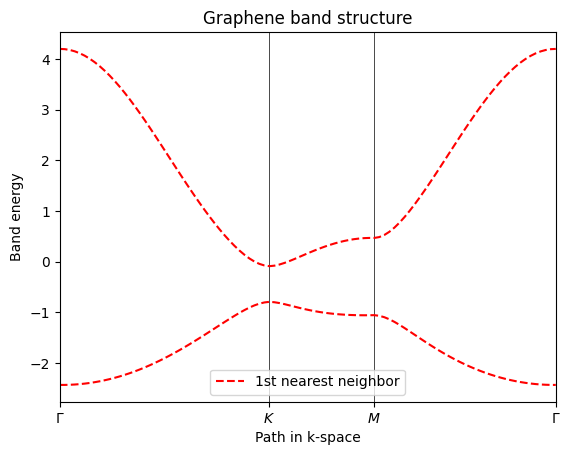

In [ ]:
fig, ax = plt.subplots()

ax.set_xlim(k_node[0], k_node[-1])
ax.set_xticks(k_node)
ax.set_xticklabels(label)

for n in range(len(k_node)):
    ax.axvline(x=k_node[n], linewidth=0.5, color="k")
    
ax.set_title("Graphene band structure")
ax.set_xlabel("Path in k-space")
ax.set_ylabel("Band energy")

# plot bands
for n in range(evals_nn.shape[1]):
    ax.plot(k_dist, evals_nn[:, n], color="r", linestyle="--", label="1st nearest neighbor" if n == 0 else "")
    # ax.plot(k_dist, evals_nnn[:, n], color="b", linestyle="-", label=f"{n_shell}th nearest neighbor" if n == 0 else "")

ax.legend()